In [ ]:
!pip install -q meeko prody rdkit vina gemmi admet-ai py3Dmol

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.0/294.0 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.5/37.5 MB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.0/37.0 MB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.9/148.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.1/103.1 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/

In [ ]:
# Get our protein
!wget https://files.rcsb.org/download/6LU7.pdb

--2026-04-26 00:22:48--  https://files.rcsb.org/download/6LU7.pdb
Resolving files.rcsb.org (files.rcsb.org)... 13.226.238.4, 13.226.238.85, 13.226.238.78, ...
Connecting to files.rcsb.org (files.rcsb.org)|13.226.238.4|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/plain]
Saving to: ‘6LU7.pdb’

6LU7.pdb                [ <=>                ] 233.51K  --.-KB/s    in 0.09s   

2026-04-26 00:22:49 (2.65 MB/s) - ‘6LU7.pdb’ saved [239112]



In [ ]:
from prody import parsePDB, writePDB

protein = parsePDB("6LU7.pdb")

# Keep protein chain A, remove waters and non-protein HETATM ligands
receptor = protein.select("chain A and protein")

writePDB("6LU7_receptor.pdb", receptor)

@> 2500 atoms and 1 coordinate set(s) were parsed in 0.04s.
DEBUG:.prody:2500 atoms and 1 coordinate set(s) were parsed in 0.04s.


'6LU7_receptor.pdb'

In [ ]:
!mk_prepare_receptor.py -i 6LU7_receptor.pdb -o 6LU7_receptor -p -v \
  --box_center -9.997 13.086 67.796 \
  --box_size 24 24 24

@> 2367 atoms and 1 coordinate set(s) were parsed in 0.04s.

Files written:
  6LU7_receptor.pdbqt <-- static (i.e., rigid) receptor input file
6LU7_receptor.box.txt <-- Vina-style box dimension file
6LU7_receptor.box.pdb <-- PDB file to visualize the grid box


In [ ]:
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors, QED, AllChem
from rdkit.Chem.FilterCatalog import FilterCatalog, FilterCatalogParams
import pandas as pd
import numpy as np
import os
from admet_ai import ADMETModel

In [ ]:
molecules = {
    "Ensitrelvir": "Cn1cnc(CN2C(=O)N(Cc3cc(F)c(F)cc3F)C(=N\\c3cc4cn(C)nc4cc3Cl)\\NC2=O)n1",
    "PF00835231": "CC(C)C[C@@H](C(=O)N[C@@H](C[C@@H]1CCNC1=O)C(=O)CO)NC(=O)C2=CC3=C(N2)C=CC=C3OC",
    "Ibuzatrelvir": "CC(C)(C)[C@@H](C(=O)N1C[C@@H](C[C@H]1C(=O)N[C@@H](C[C@@H]2CCNC2=O)C#N)C(F)(F)F)NC(=O)OC",
    "Imatinib": "Cc1ccc(cc1Nc2nccc(n2)c3cccnc3)NC(=O)c4ccc(cc4)CN5CCN(CC5)C",
    "NZ-804": "O=C(N1CC/C(CC1)=C2C3=C(CS(=O)(C4=C/2C=CC=C4)=O)C=CC=C3)C5=CN=CC6=C5NC=C6",
    "Olgotrelvir": "CC(C)C[C@@H](C(=O)N[C@@H](C[C@@H]1CCNC1=O)C(O)S(=O)(=O)O)NC(=O)C2=CC3=CC=CC=C3N2",
    "Iscartrelvir": "CNC(=O)C1=C(C(=CC(=C1)Br)[N+](=O)[O-])N[C@@H]2CCCC[C@@H]2NC(=O)C3=CN=CC4=CC=CC=C43",
    "Kaempferol": "C1=CC(=CC=C1C2=C(C(=O)C3=C(C=C(C=C3O2)O)O)O)O",
}

In [ ]:
rows = []
model = ADMETModel()
for name, smiles in molecules.items():
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print(f"Invalid SMILES for {name}")
        continue
    mol = Chem.AddHs(mol)
    params = AllChem.ETKDGv3()
    params.randomSeed = 42
    # params.maxAttempts = 1000
    params.useRandomCoords = True

    conf_id = AllChem.EmbedMolecule(mol, params)
    if (conf_id == -1):
      print(f"Skipping {name} due to issue embedding molecule")
    AllChem.MMFFOptimizeMolecule(mol)
    Chem.MolToMolFile(mol, f"{name}.sdf")
    command = f"mk_prepare_ligand.py -i {name}.sdf -o {name}.pdbqt"
    os.system(command)
    print()
    print(f"Report for {name}:")
    lipinski_violations = 4 - sum([
        Descriptors.NumHDonors(mol) <= 5, Descriptors.NumHAcceptors(mol) <= 10, Descriptors.MolWt(mol) < 500, Crippen.MolLogP(mol) < 5
    ])
    veber_violations = 2 - sum([
        Descriptors.NumRotatableBonds(mol) <= 10,
        Descriptors.TPSA(mol) <= 140
    ])
    preds = model.predict(smiles=smiles)
    print(f"Lipinski's Rule of 5 Violations: {lipinski_violations}")
    print(f"Veber's rules violations: {veber_violations}")
    print(f"Qualitative Estimation of Drug-Likeness (QED) score: {QED.qed(mol)}")
    print(f"CYP1A2 Inhibitor? {'yes' if preds['CYP1A2_Veith'] > 0.5 else 'no'}")
    print(f"CYP2C19 Inhibitor? {'yes' if preds['CYP2C19_Veith'] > 0.5 else 'no'}")
    print(f"CYP2C9 Inhibitor? {'yes' if preds['CYP2C9_Veith'] > 0.5 else 'no'}")
    print(f"CYP2D6 Inhibitor? {'yes' if preds['CYP2D6_Veith'] > 0.5 else 'no'}")
    print(f"CYP3A4 Inhibitor? {'yes' if preds['CYP3A4_Veith'] > 0.5 else 'no'}")

    rows.append({
        "name": name,
        "MW": Descriptors.MolWt(mol),
        "LogP": Crippen.MolLogP(mol),
        "HBD": Descriptors.NumHDonors(mol),
        "HBA": Descriptors.NumHAcceptors(mol),
        "Rotatable Bonds": Descriptors.NumRotatableBonds(mol),
        "Heavy Atoms": mol.GetNumHeavyAtoms(),
        "Lipinski Violations": lipinski_violations,
        "Veber Violations": veber_violations,
        "CYP1A2 Inhibitor": 'yes' if preds['CYP2C19_Veith'] > 0.5 else 'no',
        "CYP2C19 Inhibitor": 'yes' if preds['CYP2C19_Veith'] > 0.5 else 'no',
        "CYP2C9 Inhibitor": 'yes' if preds['CYP2C9_Veith'] > 0.5 else 'no',
        "CYP2D6 Inhibitor": 'yes' if preds['CYP2D6_Veith'] > 0.5 else 'no',
        "CYP3A4 Inhibitor": 'yes' if preds['CYP3A4_Veith'] > 0.5 else 'no'
    })



Report for Ensitrelvir:


model ensembles:   0%|          | 0/2 [00:00<?, ?it/s]INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Output()

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Output()

...

Output()

Output()

Output()

model ensembles: 100%|██████████| 2/2 [00:00<00:00,  3.74it/s]

Lipinski's Rule of 5 Violations: 0
Veber's rules violations: 0
Qualitative Estimation of Drug-Likeness (QED) score: 0.5458513994143424
CYP1A2 Inhibitor? yes
CYP2C19 Inhibitor? yes
CYP2C9 Inhibitor? yes
CYP2D6 Inhibitor? no
CYP3A4 Inhibitor? no


In [ ]:
df = pd.DataFrame(rows)
df

,name,MW,LogP,HBD,HBA,Rotatable Bonds,Heavy Atoms,Lipinski Violations,Veber Violations,CYP1A2 Inhibitor,CYP2C19 Inhibitor,CYP2C9 Inhibitor,CYP2D6 Inhibitor,CYP3A4 Inhibitor
0,Ensitrelvir,531.886,3.60760,1,6,5,37,1,0,no,no,yes,no,yes
1,PF00835231,472.542,0.89340,5,6,12,34,0,2,no,no,no,no,yes
2,Ibuzatrelvir,489.495,1.07108,3,6,6,34,0,1,no,no,no,no,no
3,Imatinib,493.615,4.59032,2,7,7,37,0,0,no,no,no,yes,yes
4,NZ-804,469.566,4.58830,1,4,1,34,0,0,yes,yes,yes,no,yes
5,Olgotrelvir,494.570,0.52960,6,7,12,34,1,2,no,no,no,no,no
6,Iscartrelvir,526.391,4.41820,3,6,6,34,1,0,yes,yes,yes,no,yes
7,Kaempferol,286.239,2.30530,4,6,5,21,0,0,yes,yes,yes,no,no


Molecule name: Ibuzatrelvir
Chemical Structure: 


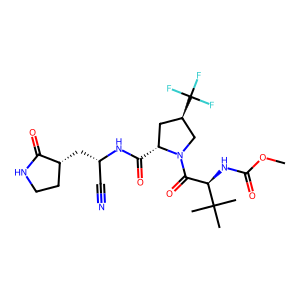

Visualization in the binding site: 



3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
import py3Dmol
from IPython.display import display
name = input("Molecule name: ")
print("Chemical Structure: ")
display(Chem.Draw.MolToImage(Chem.MolFromSmiles(molecules[name])))
print("Visualization in the binding site: ")
# Initialize viewer
view = py3Dmol.view(width=800, height=400)

# Add receptor structure
with open("6LU7_receptor.pdb") as f:
    receptor_pdb = f.read()
view.addModel(receptor_pdb, "pdb")
view.setStyle({"model": 0}, {"cartoon": {"color": "spectrum"}})
# Add box around active site (e.g., center: x,y,z; size: x,y,z)
view.addBox({'center': {'x': -10.7, 'y': 12.4, 'z': 68.8},
             'dimensions': {'w': 22, 'h': 22, 'd': 22},
             'color': 'red', 'opacity': 0.5})
try:
  with open(f"{name}_docked.pdbqt") as f:
      lines = f.readlines()

  pdb_lines = []
  for line in lines:
      if line.startswith(("ATOM", "HETATM")):
          pdb_lines.append(line[:66] + "\n")
  with open(f"{name}_docked_clean.pdb", "w") as f:
      f.writelines(pdb_lines)
      f.write("END\n")
except:
  print()

with open(f"{name}_docked_clean.pdb", "r") as f:
  poses = f.read()


# Add pose to view
view.addModel(poses, "pdbqt")
view.setStyle({"model": 1}, {"stick": {"radius": 0.3}})
view.zoomTo()
view.show()